# PPO from scratch — **V4: PPO-clip + multiple update passes**

Fifth of six. V3 extracted **one** gradient step from each 4000-step rollout. V4's whole point is
extracting **many** good steps from that same expensive batch — sample efficiency — made safe by a
clipped surrogate that stops the policy from wandering away from the data that produced it.

| Version | Concept |
|---|---|
| V0 | Vanilla PG |
| V1 | Learned value baseline |
| V2 | Fixed-horizon buffer + bootstrapping |
| V3 | GAE-λ advantage |
| **V4 (this)** | **PPO-clip surrogate + multiple update passes** |
| V5 | KL early-stop + advantage normalization |

### Why V3 can only take one step
Your V3 loss is `-(logp · A).mean()`. It's an **on-policy** gradient: valid only *at* the policy that
collected the data. Take one step and the policy has moved — the batch is now stale, and another
`-(logp·A)` step would be optimizing on data that no longer matches the policy, with no correction.
So V3 throws the batch away after a single step.

### The clipped surrogate — reuse the batch safely
PPO replaces the log-prob with an **importance ratio** between the current and the rollout policy:

$$r_t(\theta) = \frac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_\text{old}}(a_t\mid s_t)} = \exp\big(\log p_\text{new} - \log p_\text{old}\big)$$

and optimizes the **pessimistic clipped objective**

$$L = \mathbb{E}\Big[\ \min\big(r_t\,A_t,\ \ \text{clip}(r_t,\,1-\epsilon,\,1+\epsilon)\,A_t\big)\ \Big]$$

Read what the `min` + `clip` actually do, case by case (this is the whole algorithm):

| | ratio inside `[1-ε, 1+ε]` | ratio outside |
|---|---|---|
| **A > 0** (good action) | gradient flows, push prob up | clipped once `r > 1+ε` → **no more reward for going further** |
| **A < 0** (bad action) | gradient flows, push prob down | clipped once `r < 1-ε` → **no more reward for going further** |

The clip only *bites* in the direction that would move the policy **too far in the direction the
advantage already likes**. The pessimistic `min` means: when the unclipped ratio looks even better
than the clipped one, you don't get to claim it. That caps how far one batch can push you — so you
can now safely loop **`TRAIN_PI_ITERS` gradient steps** over the same rollout.

### Why the frozen buffer finally earns its keep
`A_t` and `logp_old` are the **rollout policy's** values. They must stay *fixed* across all
`TRAIN_PI_ITERS` passes — the ratio is measured against `θ_old`, not against wherever the policy
drifted to on pass 7. This is exactly the "values frozen at rollout time" property you built in
V2–V3, now load-bearing: recompute `logp_old` after the policy moves and the ratio collapses to 1,
clipping never triggers, and you're back to plain repeated VPG (which diverges). So the one new
thing the buffer stores is each action's **rollout-time `logp_old`**.

> **Single-pass PPO is just VPG.** On pass 1, `θ = θ_old` so `r ≡ 1` everywhere and the clip
> objective's gradient is identical to V3's. The clip only comes alive on pass 2+, once the policy
> has moved. That's why the *multiple passes* and the *clip* are inseparable — neither alone is PPO.

### ✅ Done-when
- The **clip unit test** (given) passes — your ratio / clip / `min` / sign are exact.
- With multiple passes, PPO should reach a good policy in **fewer epochs** than V3 (watch `goals`
  climb faster in the early epochs) at the same fixed 15-epoch budget. Final greedy stays in
  V1–V3 territory (≈ −80 to −120).
- If `goals` never take off or the return oscillates wildly, suspect the ratio (`logp_new − logp_old`
  order, or `logp_old` not frozen) or a `min`/`max` / sign slip in the surrogate.

> Kernel: `ppo`. Policy, critic, GAE buffer, and the eval harness are your V3 code — the
> buffer grows one field (`logp`), and the policy update becomes a clipped multi-pass loop.


## Imports & configuration *(given — V4 adds the clip knobs)*


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions.categorical import Categorical
import torch.nn.functional as F
import gymnasium as gym
from gymnasium.spaces import Discrete, Box

ENV_NAME   = "Acrobot-v1"
SEED       = 0
HIDDEN     = [64, 64]
LR         = 1e-2
EPOCHS     = 15
GAMMA      = 0.99

# ---- NEW in V2 --------------------------------------------------------------
STEPS_PER_EPOCH = 4000     # fixed transitions collected per epoch (replaces "32 episodes")

LAM             = 0.95     # GAE-lambda: bias/variance dial (0 = one-step TD, 1 = full reward-to-go)

CLIP_RATIO      = 0.2      # PPO clip epsilon: how far the ratio may move before the surrogate flattens
TRAIN_PI_ITERS  = 10       # gradient passes over ONE rollout (V3 did 1; the clip makes >1 safe)

VALUE_LR        = 1e-2
VALUE_FIT_ITERS = 80

print("gymnasium", gym.__version__, "| torch", torch.__version__)


gymnasium 1.3.0 | torch 2.13.0+cpu


## Policy, critic, losses, helpers *(given — your V3 code, unchanged)*


In [2]:
class MyPolicy(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN + [output_size]
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers = layers[:-1]
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> Categorical:
        return Categorical(logits=self.linear_layers(x))

    def greedy(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).argmax()

    def sample(self, x: torch.Tensor) -> torch.Tensor:
        return self(x).sample()
    
    def sample_with_logprob(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        distribution = self.forward(x)
        action = distribution.sample()
        logprob = distribution.log_prob(action)
        return action, logprob


class MyCritic(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(HIDDEN[-1], 1))
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).squeeze(-1)


def reward_to_go(rews: list[float], gamma: float = GAMMA) -> list[float]:
    """Discounted reward-to-go for a sequence. Handy for the buffer: append a bootstrap
    value to the rewards, take reward_to_go, and drop the last element."""
    n = len(rews)
    gamma_pows = gamma ** np.arange(n)
    cum_rews = []
    for i in range(n):
        left = n - i
        cr = (np.asarray(rews[i:]) * gamma_pows[:left]).sum()
        cum_rews.append(cr)
    return cum_rews


def compute_loss(policy: MyPolicy, obs: torch.Tensor, act: torch.Tensor,
                 weights: torch.Tensor) -> torch.Tensor:
    logp = policy(obs).log_prob(act)
    return -((logp) * weights).mean()


def compute_value_loss(critic: MyCritic, obs: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(critic(obs), returns)


def make_env(env_name: str = ENV_NAME, render_mode: str | None = None) -> gym.Env:
    return gym.make(env_name, render_mode=render_mode)


def set_seed(env: gym.Env, seed: int = SEED) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)


_e = make_env()
OBS_DIM = _e.observation_space.shape[0]
N_ACTS  = _e.action_space.n
MAX_STEPS = _e.spec.max_episode_steps
print(f"{ENV_NAME}: obs_dim={OBS_DIM}, n_acts={N_ACTS}, max_steps={MAX_STEPS}")
_e.close()


Acrobot-v1: obs_dim=6, n_acts=3, max_steps=500


## GAE helper + value-aware buffer *(given — your V3 code, +1 field)*

The `gae` helper is unchanged. The buffer is your V3 buffer with **one added field**: each
transition now also stores its **rollout-time log-prob** `logp`, and `get_data()` returns it as a
sixth tensor. That `logp` is `logp_old` — the denominator of the PPO ratio. *This buffer is given so
you can focus on the surrogate; note the `append(..., logp)` and the extra return value.*


In [3]:
def gae(rewards: list[float], values: list[float], final_value: float,
        lamb: float, gamma: float) -> list[float]:
    V = values + [final_value]
    n = len(rewards)
    deltas = []
    for t in range(n):
        deltas.append( rewards[t] + gamma*V[t+1] - V[t])
    deltas = np.array(deltas)
    adventages = np.zeros(n, dtype=np.float32)
    adventages[-1] = deltas[-1]
    for t in reversed(range(n-1)):
        adventages[t] =  deltas[t] + gamma * lamb * adventages[t+1]
    return adventages.tolist()

    


In [4]:
class RolloutBuffer:
    # GIVEN in V4: your V3 GAE buffer, grown by ONE field -- append() also stores the rollout-time
    # log-prob `logp` (this is logp_old, the PPO ratio's denominator), and get_data() returns it as
    # a 6th tensor: (obs, act, ret, adv, logp). Everything else is your V3 code, unchanged.
    def __init__(self, max_steps: int) -> None:
        self.obs_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.adventage_buffer = []
        self.trajectory_raw_rewards = []
        self.trajectory_raw_values = []
        self.logp_buffer = []
        self.max_steps = max_steps

    def append(self, obs: torch.Tensor, action: int, reward: float, val: float, logp: float) -> None:
        self.obs_buffer.append(obs)
        self.actions_buffer.append(action)
        self.trajectory_raw_rewards.append(reward)
        self.trajectory_raw_values.append(val)
        self.logp_buffer.append(logp)
    
    def finish_trajectory(self, terminal_value: float) -> None:
        if len(self.trajectory_raw_rewards) > 0:
            accumulated_rewards = reward_to_go(self.trajectory_raw_rewards + [terminal_value])
            adventages = gae(self.trajectory_raw_rewards, self.trajectory_raw_values, terminal_value, LAM, GAMMA)
            self.rewards_buffer += accumulated_rewards[:-1]
            self.adventage_buffer += adventages
            self.trajectory_raw_rewards = []
            self.trajectory_raw_values=[]

    def full(self) -> bool:
        return len(self.obs_buffer) >= self.max_steps
    
    def get_data(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        obs_batch_tensor = torch.stack(self.obs_buffer)
        actions_tensor = torch.tensor(self.actions_buffer)
        rewards_tensor = torch.tensor(self.rewards_buffer, dtype=torch.float32)
        adv_tensor = torch.tensor(self.adventage_buffer, dtype=torch.float32)
        logp_tensor = torch.tensor(self.logp_buffer, dtype=torch.float32)
        return obs_batch_tensor, actions_tensor, rewards_tensor, adv_tensor, logp_tensor
    


## 1. The clipped surrogate loss *(you implement)*

Write `compute_ppo_loss(policy, obs, act, adv, logp_old, clip_ratio)`:

1. `logp` = current policy's log-prob of `act` at `obs` (this is `logp_new`).
2. `ratio` = `exp(logp − logp_old)`  — the importance ratio `π_new/π_old`.
3. `clipped` = `clamp(ratio, 1−clip_ratio, 1+clip_ratio) · adv`.
4. loss = `−min(ratio·adv, clipped).mean()`  — the pessimistic surrogate, negated for gradient
   *descent*.

Watch the three classic slips: it's `min` not `max`; the clip is on the **ratio**, then multiplied
by `adv` (not a clip on `adv`); and `logp_old` is a **frozen constant** (already detached in the
buffer) — never re-derive it from the current policy inside the loop.


In [5]:
def compute_ppo_loss(policy: MyPolicy, obs: torch.Tensor, act: torch.Tensor,
                     adv: torch.Tensor, logp_old: torch.Tensor, clip_ratio: float) -> torch.Tensor:
    # TODO (V4): the clipped surrogate.
    #   logp   = policy(obs).log_prob(act)          # logp_new
    #   ratio  = exp(logp - logp_old)
    #   loss   = -min(ratio*adv, clip(ratio, 1-clip_ratio, 1+clip_ratio)*adv).mean()
    current_logp = policy(obs).log_prob(act)
    ratio = torch.exp(current_logp - logp_old)
    clipped_ratio = torch.clip(ratio, 1-clip_ratio, 1+clip_ratio)
    loss = - torch.min(ratio * adv, clipped_ratio * adv).mean()
    return loss


### 🔬 Unit test — the clip bites in the right places *(given)*

Feeds a controlled batch through your loss via a stub policy whose `log_prob` is fixed, so the ratio
is exactly known. It pins all four cases: ratio at 1 (no clip), a good action pushed too far
(`A>0, r>1+ε` → capped), a good action with a small ratio (`A>0, r<1−ε` → **not** capped, the `min`
picks the smaller unclipped term), and a bad action clipped (`A<0, r<1−ε`).


In [6]:
def _test_ppo_clip() -> None:
    clip = 0.2
    adv      = torch.tensor([ 2.0,  2.0,  2.0, -2.0, -2.0])
    ratio    = torch.tensor([ 1.0,  1.5,  0.5,  1.5,  0.5])
    logp_old = torch.zeros(5)
    logp_new = torch.log(ratio)                     # exp(logp_new - logp_old) == ratio

    class _StubPolicy:                              # ignores obs/act, returns the fixed logp
        def __call__(self, obs):     return self
        def log_prob(self, act):     return logp_new

    loss = compute_ppo_loss(_StubPolicy(), None, None, adv, logp_old, clip)

    r = ratio.numpy(); a = adv.numpy()
    surro   = np.minimum(r*a, np.clip(r, 1-clip, 1+clip)*a)   # per-sample pessimistic surrogate
    exp_loss = -surro.mean()
    np.testing.assert_allclose(loss.item(), exp_loss, rtol=1e-6,
                               err_msg="PPO-clip surrogate mismatch")
    # the clip must bite ONLY on samples 1 (A>0,r=1.5->2.4) and 4 (A<0,r=0.5->-1.6)
    assert abs(surro[1] - 2.4) < 1e-6 and abs(surro[4] - (-1.6)) < 1e-6, "clip cap wrong"
    assert abs(surro[2] - 1.0) < 1e-6, "A>0 with small ratio must stay UNclipped (min picks r*adv)"
    print("PPO-clip OK  surrogate:", np.round(surro, 3), " loss:", round(loss.item(), 4))

_test_ppo_clip()


PPO-clip OK  surrogate: [ 2.   2.4  1.  -3.  -1.6]  loss: -0.16


## 2. Rollout + multi-pass update *(you implement)*

Two edits to your V3 `train_one_epoch`:

1. **Store `logp_old` during the rollout.** When you sample the action, grab its log-prob from the
   *same* distribution and pass it to `append(obs, action, reward, val, logp)`:
   ```
   dist   = policy_net(obs)
   action = dist.sample()
   logp   = dist.log_prob(action)     # under no_grad -> this is logp_old, frozen
   ```
2. **Loop the policy update `TRAIN_PI_ITERS` times** over the one batch, each pass calling
   `compute_ppo_loss(policy_net, obs, act, adv, logp_old, CLIP_RATIO)` and stepping. The critic fit
   loop (`VALUE_FIT_ITERS` on `ret`) is unchanged. `get_data()` now returns **six** values.

Return `(batch_rets, batch_lens, v_loss, n_goals)`, same as V3. (Optional but nice: also track the
mean KL `≈ (logp_old − logp_new).mean()` after the passes — you'll want it in V5 for early-stopping.)


In [7]:
def train_one_epoch(env: gym.Env, policy_net: MyPolicy, critic_net: MyCritic,
                    policy_optimizer: Adam, critic_optimizer: Adam,
                    ) -> tuple[list[float], list[int], float, int]:
    # TODO (V4): your V3 rollout, with two edits --
    #   (1) store logp_old for each action: dist=policy_net(obs); action=dist.sample();
    #       logp=dist.log_prob(action); append(obs, action, reward, val, logp).
    #   (2) update the policy with TRAIN_PI_ITERS passes of compute_ppo_loss over the SAME batch
    #       (adv + logp_old frozen from get_data). Critic fit to ret is unchanged.
    #   Return (batch_rets, batch_lens, v_loss, n_goals).  get_data() -> obs, act, ret, adv, logp.
    buffer = RolloutBuffer(STEPS_PER_EPOCH)
    n_goals = 0
    batch_lens =[]
    batch_rets = []
    while not buffer.full():
        obs = torch.tensor(env.reset()[0], dtype = torch.float32)
        done = False
        while not done:
            with torch.no_grad():
                action, log_p =policy_net.sample_with_logprob(obs)
                action, log_p = int(action), log_p.item()
                value = critic_net(obs).item()
            next_obs, rew, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            timeout = truncated and not terminated
            buffer.append(obs,action, rew, value, log_p)
            obs = torch.tensor(next_obs, dtype = torch.float32)

            if buffer.full() and not done:
                done, timeout = True, True
            if done:
                if not buffer.full():
                    batch_lens.append(len(buffer.trajectory_raw_rewards))
                    batch_rets.append(sum(buffer.trajectory_raw_rewards))
                if not timeout:
                    final_v = 0
                    n_goals +=1
                else:
                    with torch.no_grad():
                        final_v = critic_net(obs).item()
                buffer.finish_trajectory(final_v)
    obs_batch_tensor, actions_tensor, rewards_tensor, adventage_tensor, logp_old_tensor = buffer.get_data()
    for _ in range(VALUE_FIT_ITERS):
        critic_optimizer.zero_grad()
        critic_loss = compute_value_loss(critic_net, obs_batch_tensor, rewards_tensor)
        critic_loss.backward()
        critic_optimizer.step()
    
    for _ in range(TRAIN_PI_ITERS):
        policy_optimizer.zero_grad()
        loss = compute_ppo_loss(policy_net, obs_batch_tensor, actions_tensor, adventage_tensor, logp_old_tensor, CLIP_RATIO)
        loss.backward()
        policy_optimizer.step()
        
    return batch_rets, batch_lens, critic_loss.item(), n_goals


## Evaluation & recording harness *(given — your V1 code, inline GIF)*


In [8]:
def greedy_action(obs: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return policy_net.greedy(torch.tensor(obs, dtype=torch.float32))


def evaluate(env_name: str = ENV_NAME, n_episodes: int = 10, seed: int = 1000) -> tuple[float, float]:
    """Average greedy return over n_episodes. Our comparison metric."""
    env = make_env(env_name)
    rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            obs, r, terminated, truncated, _ = env.step(greedy_action(obs))
            done = terminated or truncated
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def record_gif(out_path: str, env_name: str = ENV_NAME, episodes: int = 3, fps: int = 15) -> None:
    """Greedy rollout -> GIF saved to disk AND shown inline (animated) in the notebook."""
    try:
        import imageio
        env = make_env(env_name, render_mode="rgb_array")
        frames = []
        for _ in range(episodes):
            obs, done = env.reset()[0], False
            while not done:
                frames.append(env.render())
                obs, _, terminated, truncated, _ = env.step(greedy_action(obs))
                done = terminated or truncated
        env.close()
        imageio.mimsave(out_path, frames, fps=fps)
        print(f"saved {len(frames)} frames -> {out_path}")
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception as ex:
        print("record_gif skipped (likely headless):", repr(ex))


## Train *(given — drives your code)*


In [9]:
env = make_env()
set_seed(env, SEED)

policy_net = MyPolicy(OBS_DIM, N_ACTS)
policy_optimizer  = Adam(policy_net.parameters(), lr=LR/TRAIN_PI_ITERS)

critic_net = MyCritic(OBS_DIM)
critic_optimizer = Adam(critic_net.parameters(), lr=VALUE_LR)


for epoch in range(EPOCHS):
    batch_rets, batch_lens, v_loss, n_goals = train_one_epoch(env, policy_net, critic_net, policy_optimizer, critic_optimizer)
    avg_ret = np.mean(batch_rets) if len(batch_rets) else float("nan")
    avg_len = np.mean(batch_lens) if len(batch_lens) else float("nan")
    print("epoch %3d \t return %8.1f \t ep_len %6.1f \t v_loss %8.2f \t goals %3d" %
          (epoch, avg_ret, avg_len, v_loss, n_goals))
env.close()


epoch   0 	 return   -500.0 	 ep_len  500.0 	 v_loss  1570.97 	 goals   0


epoch   1 	 return   -500.0 	 ep_len  500.0 	 v_loss   284.10 	 goals   0


epoch   2 	 return   -492.0 	 ep_len  492.1 	 v_loss   116.32 	 goals   1


epoch   3 	 return   -383.0 	 ep_len  384.0 	 v_loss   126.97 	 goals  10


epoch   4 	 return   -261.7 	 ep_len  262.7 	 v_loss   114.13 	 goals  15


...

epoch  10 	 return    -97.1 	 ep_len   98.1 	 v_loss   168.19 	 goals  40


epoch  11 	 return    -96.1 	 ep_len   97.1 	 v_loss   112.60 	 goals  41


epoch  12 	 return    -95.1 	 ep_len   96.1 	 v_loss   142.60 	 goals  41


epoch  13 	 return    -89.2 	 ep_len   90.2 	 v_loss    85.66 	 goals  44


epoch  14 	 return    -86.5 	 ep_len   87.5 	 v_loss    79.16 	 goals  45


## ✅ Verify V4 *(given)*


ratio: mean 1.000  min 1.000  max 1.000  (all ~1.0 here since this is the SAME policy -- the clip only bites mid-update)



V4 greedy return on Acrobot-v1: -85.3 +/- 12.3
Watch the training print: goals should climb FASTER (in fewer epochs) than V3.


saved 228 frames -> v4_baseline.gif


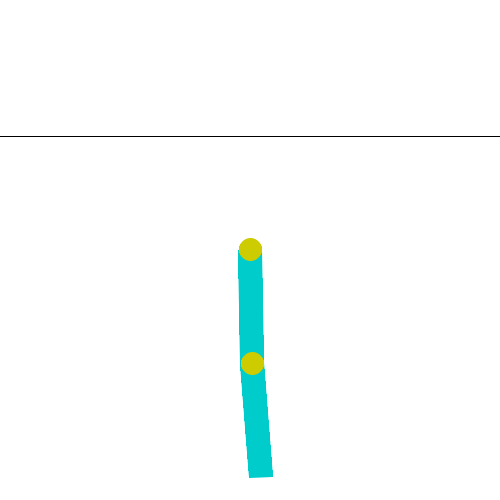

In [10]:
# clip-activity diagnostic: how often did the ratio get clipped on a fresh batch?
def clip_activity(steps: int = STEPS_PER_EPOCH) -> None:
    b = RolloutBuffer(steps)
    e = make_env(); o = e.reset()[0]
    for t in range(steps):
        obs_t = torch.tensor(o, dtype=torch.float32)
        with torch.no_grad():
            dist = policy_net(obs_t); a = dist.sample(); lp = dist.log_prob(a); v = critic_net(obs_t).item()
        o2, r, term, trunc, info = e.step(int(a)); b.append(obs_t, int(a), r, v, lp.item()); o = o2
        d = term or trunc
        timeout = trunc and not term; epoch_ended = t == steps - 1
        if d or epoch_ended:
            genuine = d and not timeout and not epoch_ended
            with torch.no_grad():
                last_v = 0.0 if genuine else critic_net(torch.tensor(o, dtype=torch.float32)).item()
            b.finish_trajectory(last_v); o = e.reset()[0]
    e.close()
    ob, ac, ret, adv, logp_old = b.get_data()
    with torch.no_grad():
        ratio = torch.exp(policy_net(ob).log_prob(ac) - logp_old)   # ~1 on a fresh batch (same policy)
    print(f"ratio: mean {ratio.mean():.3f}  min {ratio.min():.3f}  max {ratio.max():.3f}  "
          f"(all ~1.0 here since this is the SAME policy -- the clip only bites mid-update)")

clip_activity()

mean_ret, std_ret = evaluate(n_episodes=30)
print(f"\nV4 greedy return on {ENV_NAME}: {mean_ret:.1f} +/- {std_ret:.1f}")
print("Watch the training print: goals should climb FASTER (in fewer epochs) than V3.")
record_gif("v4_baseline.gif")


---
### When V4 is done
Ping me with your eval line + the `goals` progression (I'll compare its *early-epoch* slope against
V3 — that's where PPO's multi-pass sample efficiency shows) and I'll review the ratio/clip/frozen-
`logp_old` before generating the finale **V5 — KL early-stop + advantage normalization**: instead of
a fixed `TRAIN_PI_ITERS`, you'll stop the passes once the policy has moved a target KL from `θ_old`
(so you never over-optimize a batch), and you'll standardize the advantages per-batch (mean 0, std 1)
for a steadier gradient scale. That's full PPO.
